### Learning Objectives:
1. Understand the mathematical foundations of Simple Linear Regression.
2. Implement the Normal Equation for matrix-based optimization.
3. Extend these concepts to Multiple Linear Regression with two features.
4. Visualize results in both 2D and interactive 3D space.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
plt.style.use('seaborn-v0_8-muted')

In [2]:
df = pd.DataFrame({
    'house_size':  [1852, 1975, 1176, 1550, 1458, 2689, 2259, 2763, 1325, 1992],
    'beds': [2, 2, 1, 2, 2, 3, 3, 3, 2, 4],
    'house_price': [316000, 277000, 155000, 253000, 211000, 329000, 317000, 360000, 204000, 250000],
})

df

,house_size,beds,house_price
0,1852,2,316000
1,1975,2,277000
2,1176,1,155000
3,1550,2,253000
4,1458,2,211000
5,2689,3,329000
6,2259,3,317000
7,2763,3,360000
8,1325,2,204000
9,1992,4,250000


We have a dataset of house sizes, number of bedrooms, and their corresponding prices. Our goal is to model how size and beds influence the price.

## Simple Linear Regression


Before we start modeling, let's visualize the relationship between `house_size` (our feature $x$) and `house_price` (our target $y$).

$$\hat{y} = w \cdot x + b$$

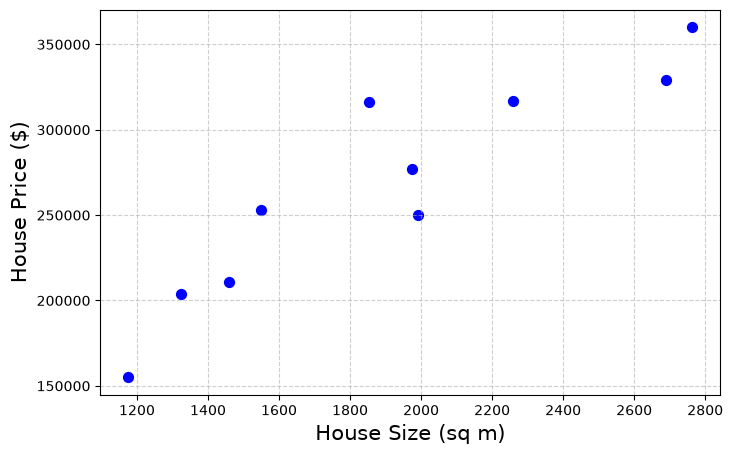

In [3]:
x = df['house_size'].values
y = df['house_price'].values

plt.figure(figsize=(8, 5))
plt.scatter(x, y, color='blue', label='Actual Data', s=50)
plt.xlabel('House Size (sq m)', fontsize=15)
plt.ylabel('House Price ($)', fontsize=15)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Approach 1: Algebraic Formulas

In simple linear regression ($ŷ = wx + b$), we can calculate the slope ($w$) and the intercept ($b$) using the following formulas:

$$w = \frac{n \sum xy - \sum x \sum y}{n \sum x^2 - (\sum x)^2}$$

$$b = \frac{\sum y \sum x^2 - \sum x \sum xy}{n \sum x^2 - (\sum x)^2}$$

In [4]:
n = len(x)
sum_x = np.sum(x)
sum_y = np.sum(y)
sum_xy = np.sum(x * y)
sum_x2 = np.sum(x**2)

# Calculate slope (w) and intercept (b)
w = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x**2)
b = (sum_y * sum_x2 - sum_x * sum_xy) / (n * sum_x2 - sum_x**2)

print(f"Formula-based results: \n w = {w:.2f}, \n b = {b:.2f}")

Formula-based results: 
 w = 108.35, 
 b = 60919.44


### Approach 2: Matrix Approach (Normal Equation)

Linear regression can also be solved using linear algebra. We represent our parameters in a vector $\theta = [b, w]^T$ and solve the equation:

$$\begin{bmatrix} b \\ w \end{bmatrix} = (X^T X)^{-1} X^T Y$$

In [5]:
x

array([1852, 1975, 1176, 1550, 1458, 2689, 2259, 2763, 1325, 1992])

In [11]:
X_mat = np.column_stack((np.ones(len(x)),x))

Y_mat= y.reshape(-1,1)

theta = np.linalg.inv(X_mat.T @ X_mat) @ X_mat.T @ Y_mat


b ,w = theta[0][0] , theta[1][0]


print(f"Matrix-based results: \n w = {w: .2f} , \n b = {b:.2f}")

Matrix-based results: 
 w =  108.35 , 
 b = 60919.44


### Fitted Line

Now we plot the regression line $\hat{y} = wx + b$ over our scatter plot to see how well it fits the data.

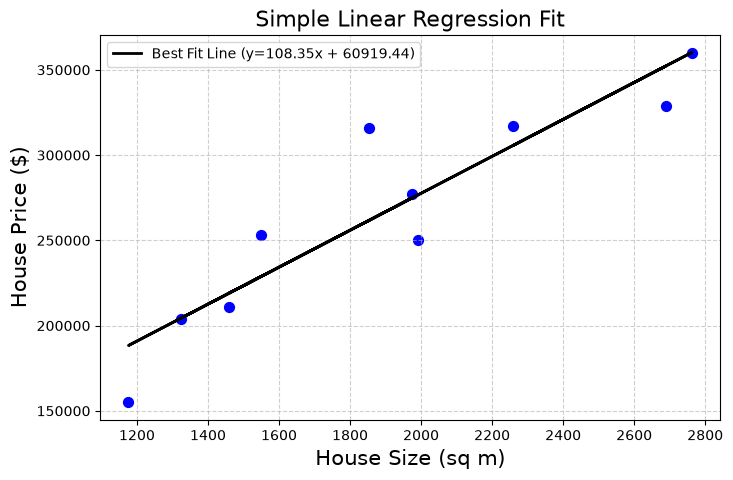

In [12]:
x = df['house_size'].values
y = df['house_price'].values

plt.figure(figsize=(8, 5))
plt.title('Simple Linear Regression Fit', fontsize=16)
plt.scatter(x, y, color='blue', s=50)
plt.plot(x, w*x + b, color='black', linewidth=2, label=f'Best Fit Line (y={w:.2f}x + {b:.2f})')
plt.xlabel('House Size (sq m)', fontsize=15)
plt.ylabel('House Price ($)', fontsize=15)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

### Making Predictions

Now that we have our model parameters ($w$ and $b$), we can predict the price for any house size using the linear equation:

$$\text{Predicted Price} = w \times (\text{House Size}) + b$$

Let's test this with a few example sizes.

In [13]:
def predict(w, b, x):
    return w * x + b

In [14]:
house_size = 2000
predicted_price = predict(w, b, house_size)

print(f"A house of {house_size} sq m is predicted to cost: ${predicted_price:,.2f}")

A house of 2000 sq m is predicted to cost: $277,612.08


In [15]:
new_house_sizes = np.array([1500, 2000, 2500, 3000, 3500])
predicted_new_house_prices = predict(w, b, new_house_sizes)

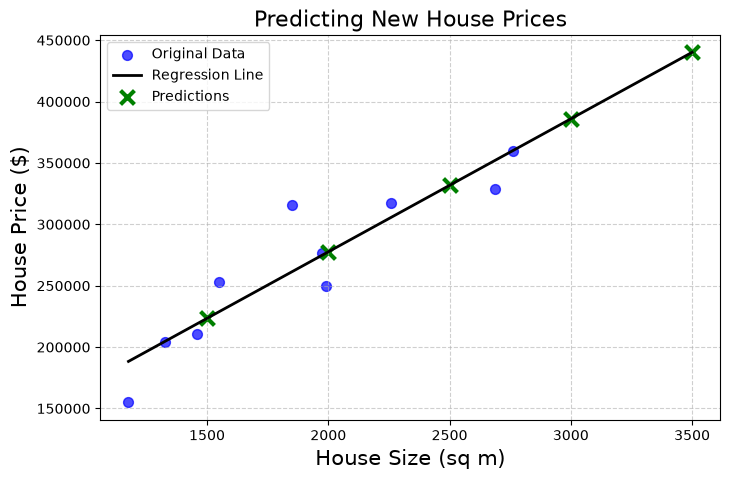

In [16]:
plt.figure(figsize=(8, 5))
plt.scatter(x, y, color='blue', alpha=0.7, label='Original Data', s = 50)
x_range = np.linspace(x.min(), new_house_sizes.max(), 100)
y_range = w * x_range + b
plt.plot(x_range, y_range, color='black', linewidth=2, label='Regression Line')
plt.scatter(new_house_sizes, predicted_new_house_prices, color='green', marker='x', s=100, linewidth=3, label='Predictions')
plt.title('Predicting New House Prices', fontsize = 16)
plt.xlabel('House Size (sq m)', fontsize = 15)
plt.ylabel('House Price ($)', fontsize = 15)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Multiple Linear Regression

In this section, we extend our model to use two features: `house_size` ($x_1$) and `beds` ($x_2$). The goal is to find the plane that best fits the data according to the equation:

$$\hat{y} = w_1 \cdot x_1 + w_2 \cdot x_2 + b$$

### Approach 1: Algebraic Formulas (2 Features)

For a model with two independent variables, the coefficients can be solved using these specific formulas:

$$w_1 = \frac{(\sum x_2^2)(\sum x_1 y) - (\sum x_1 x_2)(\sum x_2 y)}{(\sum x_1^2)(\sum x_2^2) - (\sum x_1 x_2)^2}$$

$$w_2 = \frac{(\sum x_1^2)(\sum x_2 y) - (\sum x_1 x_2)(\sum x_1 y)}{(\sum x_1^2)(\sum x_2^2) - (\sum x_1 x_2)^2}$$

$$b = \frac{\sum y - w_1 \sum x_1 - w_2 \sum x_2}

In [17]:
x1 = df['house_size'].values
x2 = df['beds'].values
y = df['house_price'].values
n = len(y)

x1_dev = x1 - np.mean(x1)
x2_dev = x2 - np.mean(x2)
y_dev = y - np.mean(y)

sum_x1_2 = np.sum(x1_dev**2)
sum_x2_2 = np.sum(x2_dev**2)
sum_x1_y = np.sum(x1_dev * y_dev)
sum_x2_y = np.sum(x2_dev * y_dev)
sum_x1_x2 = np.sum(x1_dev * x2_dev)

denom = (sum_x1_2 * sum_x2_2) - (sum_x1_x2**2)

w1_alg = (sum_x2_2 * sum_x1_y - sum_x1_x2 * sum_x2_y) / denom
w2_alg = (sum_x1_2 * sum_x2_y - sum_x1_x2 * sum_x1_y) / denom
b_alg = np.mean(y) - w1_alg * np.mean(x1) - w2_alg * np.mean(x2)

print(f"Corrected Algebraic Results:\n  w1 = {w1_alg:.2f}\n  w2 = {w2_alg:.2f}\n  b  = {b_alg:.2f}")

Corrected Algebraic Results:
  w1 = 119.08
  w2 = -9928.68
  b  = 64308.04


### Approach 2: Matrix Approach

The matrix approach is generalized for any number of features:

$$\begin{bmatrix} b \\ w_1 \\ w_2 \end{bmatrix} = (X^T X)^{-1} X^T Y$$

In [18]:
X_multi = np.column_stack((np.ones(n), x1, x2))
Y_multi = y.reshape(-1, 1)

theta_multi = np.linalg.inv(X_multi.T @ X_multi) @ X_multi.T @ Y_multi
b_multi, w1_multi, w2_multi = theta_multi.ravel()

print(f"Matrix-based results: \n w1={w1_multi:.2f}, \n w2={w2_multi:.2f}, \n b={b_multi:.2f}")

Matrix-based results: 
 w1=119.08, 
 w2=-9928.68, 
 b=64308.04


### Visualization

With two features, our regression "line" becomes a 2D plane in 3D space.

In [19]:
import plotly.graph_objects as go

x1_range = np.linspace(df['house_size'].min(), df['house_size'].max(), 20)
x2_range = np.linspace(df['beds'].min(), df['beds'].max(), 20)
X1_mesh, X2_mesh = np.meshgrid(x1_range, x2_range)
Y_mesh = w1_multi * X1_mesh + w2_multi * X2_mesh + b_multi

fig = go.Figure()

# Add the regression plane
fig.add_trace(go.Surface(x=x1_range, y=x2_range, z=Y_mesh,
                         colorscale='Reds', opacity=0.5, name='Regression Plane'))

# Add the actual data points
fig.add_trace(go.Scatter3d(x=df['house_size'], y=df['beds'], z=df['house_price'],
                           mode='markers',
                           marker=dict(size=5, color='blue', symbol='circle'),
                           name='Actual Data'))

# Set labels and title
fig.update_layout(title='Interactive 3D Multiple Linear Regression',
                  scene=dict(
                      xaxis_title='House Size (sq ft)',
                      yaxis_title='Beds',
                      zaxis_title='Price ($)'),
                  margin=dict(l=0, r=0, b=0, t=40))

fig.show()